# 02c — FoldX interaction-energy validation of EGF–EGFR hotspot candidates

**PEARL / PDB 3NJP — extracellular EGF–EGFR interface**

This notebook is a follow-up to notebook **02b**. In the implemented system, **chain B is extracellular EGFR** and **chain D is EGF**.

Notebook 02b used the ΔΔG reported by FoldX `BuildModel` as a **mutation-energy sensitivity** metric. That quantity is useful for alanine scanning, but it does not by itself isolate the energetic contribution of the B–D interaction.

Here we perform a targeted control using FoldX `AnalyseComplex` on WT and alanine mutants and compare the **inter-chain interaction-energy score** for chains B and D.

> Important: the FoldX interaction-energy score is an empirical FoldX energy term. In this notebook it is **not called an experimental binding free energy** and is not interpreted as proof of biological inhibition.

## Analysis logic

1. Check FoldX and the repaired B–D structure used by the existing workflow.
2. Reuse the same chain-D alanine-scanning positions from 02b.
3. Generate each mutant with multiple `BuildModel` runs (default: 5).
4. Run `AnalyseComplex` for WT and each mutant structure.
5. Extract the B–D interaction-energy value from the FoldX output.
6. Calculate `ΔInteraction = Interaction_mutant − Interaction_WT`.
7. Aggregate mutant replicates (mean, SD, n).
8. Compare the result with the original 02b BuildModel mutation-sensitivity classification.

**Sign convention:** the notebook reports the raw FoldX convention and the arithmetic difference above. A positive or negative difference is interpreted only after inspecting the actual `AnalyseComplex` output/header. No universal “validated binding-hotspot threshold” is assumed.

In [3]:
from pathlib import Path
import os, re, shutil, subprocess, statistics
import pandas as pd
import numpy as np

# ---- USER/WORKFLOW SETTINGS ----
FOLDX = "/Users/robertobruzzese/Downloads/foldx5_MacSilicon_0/foldx5.1_20261231"
WT_PDB = Path(
    "/Users/robertobruzzese/Desktop/venv/outputs/foldx_buildmodel/3NJP_BD_clean_Repair.pdb"
)
CHAIN_RECEPTOR = "B"   # extracellular EGFR
CHAIN_LIGAND = "D"     # EGF
NUMBER_OF_RUNS = 5

# Operational threshold inherited from 02b: this applies ONLY to the
# BuildModel mutation-energy sensitivity metric, not to validated binding.
BUILDMODEL_SENSITIVITY_THRESHOLD = 1.5

# Optional exploratory threshold for ΔInteraction.
# Leave None unless you intentionally want an exploratory categorization.
EXPLORATORY_INTERACTION_THRESHOLD = None

WORKDIR = Path("foldx_02c_binding_validation")
WORKDIR.mkdir(exist_ok=True)

print("FoldX:", shutil.which(FOLDX) or FOLDX)
print("WT input:", WT_PDB.resolve())
print("Workdir:", WORKDIR.resolve())

if shutil.which(FOLDX) is None and not Path(FOLDX).exists():
    raise FileNotFoundError(
        "FoldX executable not found. Set environment variable FOLDX_BIN "
        "or place 'foldx' on PATH."
    )
if not WT_PDB.exists():
    raise FileNotFoundError(
        f"{WT_PDB} not found. Copy/use the repaired B–D structure produced by 02b "
        "before running this notebook."
    )

FoldX: /Users/robertobruzzese/Downloads/foldx5_MacSilicon_0/foldx5.1_20261231
WT input: /Users/robertobruzzese/Desktop/venv/outputs/foldx_buildmodel/3NJP_BD_clean_Repair.pdb
Workdir: /Users/robertobruzzese/Desktop/venv/foldx_02c_binding_validation


## Residues to test

To avoid silently changing the original experiment, this cell first tries to recover the chain-D mutation positions from the existing 02b notebook in the current directory. If automatic recovery is not possible, it stops and asks you to supply the exact positions rather than inventing them.

In [5]:
from pathlib import Path
import pandas as pd

SCAN_CSV = Path(
    "/Users/robertobruzzese/Desktop/venv/outputs/"
    "foldx_buildmodel_scan_residues.csv"
)

if not SCAN_CSV.exists():
    raise FileNotFoundError(
        f"File originale 02b non trovato: {SCAN_CSV}"
    )

scan_02b = pd.read_csv(SCAN_CSV)

print("Colonne disponibili:")
print(scan_02b.columns.tolist())

# Manteniamo esattamente i residui della catena D
scan_D = scan_02b[
    scan_02b["chain"].astype(str) == "D"
].copy()

positions = (
    scan_D["resseq"]
    .dropna()
    .astype(int)
    .drop_duplicates()
    .sort_values()
    .tolist()
)

print(f"Residui chain D recuperati dal 02b: {len(positions)}")
print(positions)

if len(positions) != 29:
    raise RuntimeError(
        f"Attesi 29 residui dal 02b, trovati {len(positions)}. "
        "Non procedere finché la discrepanza non è chiarita."
    )

Colonne disponibili:
['chain', 'resseq', 'resname', 'node', 'aa1', 'n_contacts', 'degree', 'betweenness', 'graph_proxy_score', 'foldx_buildmodel_mutation', 'scan_required']
Residui chain D recuperati dal 02b: 29
[9, 10, 11, 12, 13, 15, 16, 21, 23, 26, 28, 31, 32, 33, 35, 37, 38, 39, 40, 41, 43, 44, 45, 46, 47, 48, 49, 50, 51]


## Generate alanine mutants with replicates

This uses FoldX `BuildModel` only to generate the mutant structures. `NUMBER_OF_RUNS=5` is the default here so that the subsequent interaction-energy analysis is not based on a single mutant realization.

FoldX mutation syntax can depend on the PDB/residue naming convention. The generated mutation list is printed before execution; inspect it before continuing.

In [6]:
# FoldX individual_list syntax used here: originalAA + chain + residue + mutantAA + ';'
# We infer original residue identity directly from ATOM records of chain D.

AA3_TO_1 = {
    "ALA":"A","ARG":"R","ASN":"N","ASP":"D","CYS":"C","GLN":"Q","GLU":"E","GLY":"G",
    "HIS":"H","ILE":"I","LEU":"L","LYS":"K","MET":"M","PHE":"F","PRO":"P","SER":"S",
    "THR":"T","TRP":"W","TYR":"Y","VAL":"V"
}

def pdb_chain_residues(pdb_path, chain):
    found = {}
    for line in pdb_path.read_text(errors="ignore").splitlines():
        if line.startswith("ATOM") and len(line) >= 26 and line[21].strip() == chain:
            resn = line[17:20].strip()
            try:
                resi = int(line[22:26].strip())
            except ValueError:
                continue
            found.setdefault(resi, resn)
    return found

d_res = pdb_chain_residues(WT_PDB, CHAIN_LIGAND)
mutations = []
for pos in positions:
    if pos not in d_res:
        raise ValueError(f"Residue D:{pos} not found in {WT_PDB}")
    aa3 = d_res[pos]
    if aa3 not in AA3_TO_1:
        raise ValueError(f"Unsupported residue name {aa3} at D:{pos}")
    wt1 = AA3_TO_1[aa3]
    if wt1 == "A":
        print(f"Skipping D:{pos}: already alanine")
        continue
    mutations.append({"position":pos, "wt":wt1, "mutation":f"{wt1}{CHAIN_LIGAND}{pos}A;"})

mut_df = pd.DataFrame(mutations)
display(mut_df)

,position,wt,mutation
0,9,S,SD9A;
1,10,H,HD10A;
2,11,D,DD11A;
3,12,G,GD12A;
4,13,Y,YD13A;
5,15,L,LD15A;
6,16,H,HD16A;
7,21,M,MD21A;
8,23,I,ID23A;
9,26,L,LD26A;


In [12]:
# Copy WT into work directory and write FoldX mutant list.
wt_work = WORKDIR / WT_PDB.name
if wt_work.resolve() != WT_PDB.resolve():
    shutil.copy2(WT_PDB, wt_work)

mut_file = WORKDIR / "individual_list_02c.txt"
mut_file.write_text("\n".join(mut_df["mutation"]) + "\n", encoding="utf-8")
print(mut_file.read_text())

print("Mutation file:", mut_file.resolve())
print("Exists:", mut_file.resolve().exists())
# IMPORTANT: this cell actually runs FoldX.
cmd = [
    FOLDX, "--command=BuildModel",
    f"--pdb={wt_work.name}",
    f"--pdb-dir={WORKDIR.resolve()}",
    f"--output-dir={WORKDIR.resolve()}",
    f"--mutant-file={mut_file.resolve()}",
    f"--numberOfRuns={NUMBER_OF_RUNS}",
    "--out-pdb=true",
]
print("Running:", " ".join(map(str, cmd)))
res = subprocess.run(cmd, text=True, capture_output=True)
print(res.stdout)
foldx_output = (res.stdout or "") + "\n" + (res.stderr or "")

if res.returncode != 0 or "No mutation file is provided" in foldx_output:
    raise RuntimeError(
        "FoldX BuildModel did not execute correctly.\n\n"
        + foldx_output
    )
    print(res.stderr)
    raise RuntimeError("FoldX BuildModel failed.")

SD9A;
HD10A;
DD11A;
GD12A;
YD13A;
LD15A;
HD16A;
MD21A;
ID23A;
LD26A;
KD28A;
CD31A;
ND32A;
CD33A;
VD35A;
YD37A;
ID38A;
GD39A;
ED40A;
RD41A;
QD43A;
YD44A;
RD45A;
DD46A;
LD47A;
KD48A;
WD49A;
WD50A;
ED51A;

Mutation file: /Users/robertobruzzese/Desktop/venv/foldx_02c_binding_validation/individual_list_02c.txt
Exists: True
Running: /Users/robertobruzzese/Downloads/foldx5_MacSilicon_0/foldx5.1_20261231 --command=BuildModel --pdb=3NJP_BD_clean_Repair.pdb --pdb-dir=/Users/robertobruzzese/Desktop/venv/foldx_02c_binding_validation --output-dir=/Users/robertobruzzese/Desktop/venv/foldx_02c_binding_validation --mutant-file=/Users/robertobruzzese/Desktop/venv/foldx_02c_binding_validation/individual_list_02c.txt --numberOfRuns=5 --out-pdb=true
   ********************************************
   ***                                      ***
   ***             FoldX 5.1 (c)            ***
   ***                                      ***
   ***     code by the FoldX Consortium     ***
   ***              

## AnalyseComplex — WT and mutant structures

The next cells deliberately inspect FoldX output files rather than assuming a fixed column number. FoldX versions can differ in formatting. We search for an interaction-energy-like header and stop if the output cannot be identified unambiguously.

In [8]:
def run_analyse_complex(pdb_path):
    cmd = [
        FOLDX, "--command=AnalyseComplex",
        f"--pdb={pdb_path.name}",
        f"--pdb-dir={pdb_path.parent.resolve()}",
        f"--output-dir={pdb_path.parent.resolve()}",
        f"--analyseComplexChains={CHAIN_RECEPTOR},{CHAIN_LIGAND}",
    ]
    r = subprocess.run(cmd, text=True, capture_output=True)
    if r.returncode != 0:
        print(r.stdout, r.stderr)
        raise RuntimeError(f"AnalyseComplex failed for {pdb_path.name}")
    return r

# WT first
run_analyse_complex(wt_work)

# Show newly generated AnalyseComplex-related files so the format is visible.
for p in sorted(WORKDIR.glob("*")):
    if any(k in p.name.lower() for k in ["interaction", "summary", "analyse"]):
        print("\n###", p.name)
        try:
            print("\n".join(p.read_text(errors="ignore").splitlines()[:12]))
        except Exception:
            pass


### Interaction_3NJP_BD_clean_Repair_AC.fxout
FoldX 5.1 (2011)
by the FoldX Consortium 
Jesper Borg, Frederic Rousseau, Joost Schymkowitz,
Luis Serrano and Francois Stricher
------------------------------------------------------

PDB file analysed: batch
Output type: AnalyseComplex
Pdb	Group1	Group2	IntraclashesGroup1	IntraclashesGroup2	Interaction Energy	Backbone Hbond	Sidechain Hbond	Van der Waals	Electrostatics	Solvation Polar	Solvation Hydrophobic	Van der Waals clashes	entropy sidechain	entropy mainchain	sloop_entropy	mloop_entropy	cis_bond	torsional clash	backbone clash	helix dipole	water bridge	disulfide	electrostatic kon	partial covalent bonds	energy Ionisation	Entropy Complex	Number of Residues	Interface Residues	Interface Residues Clashing	Interface Residues VdW Clashing	Interface Residues BB Clashing
/Users/robertobruzzese/Desktop/venv/foldx_02c_binding_validation/3NJP_BD_clean_Repair.pdb	B	D	77.4432	8.21698	-36.5948	-7.2088	-8.33783	-28.9173	-4.77746	32.3615	-41.6777	1.3322

In [10]:
def parse_interaction_energy(path):
    lines = [ln.rstrip("\n") for ln in path.read_text(errors="ignore").splitlines() if ln.strip()]
    # Look for a tab-separated header containing an interaction-energy field.
    for i, ln in enumerate(lines):
        cols = [x.strip() for x in ln.split("\t")]
        candidates = [j for j,c in enumerate(cols)
                      if "interaction" in c.lower() and "energy" in c.lower()]
        if candidates and i + 1 < len(lines):
            vals = [x.strip() for x in lines[i+1].split("\t")]
            if len(vals) > max(candidates):
                try:
                    return float(vals[candidates[0]]), cols[candidates[0]], ln, lines[i+1]
                except ValueError:
                    pass
    raise ValueError(
        f"Could not unambiguously identify an Interaction Energy column in {path}. "
        "Inspect the printed FoldX header and adapt parser only to your installed FoldX format."
    )

def find_ac_output_for(stem):
    # Per questa analisi vogliamo esplicitamente l'output
    # Interaction_* prodotto da FoldX AnalyseComplex.
    preferred = sorted(WORKDIR.glob(f"Interaction_{stem}*_AC.fxout"))

    if not preferred:
        # fallback più permissivo per eventuali differenze di naming
        preferred = sorted(
            p for p in WORKDIR.glob(f"*{stem}*")
            if p.is_file() and "interaction" in p.name.lower()
        )

    parsed = []

    for p in preferred:
        try:
            val, label, header, row = parse_interaction_energy(p)
            parsed.append((p, val, label, header, row))
        except Exception:
            pass

    if len(parsed) == 0:
        raise RuntimeError(
            f"No parseable Interaction AnalyseComplex output found for {stem}. "
            "Inspect the Interaction_*.fxout file before continuing."
        )

    if len(parsed) > 1:
        print(
            f"WARNING: found {len(parsed)} parseable Interaction files for {stem}. "
            "Using the first one:"
        )
        for x in parsed:
            print(" ", x[0])

    return parsed[0]

wt_result = find_ac_output_for(wt_work.stem)
print("WT file:", wt_result[0].name)
print("Energy field:", wt_result[2])
print("WT interaction energy:", wt_result[1])
print("Header:", wt_result[3])
print("Row:", wt_result[4])

WT file: Interaction_3NJP_BD_clean_Repair_AC.fxout
Energy field: Interaction Energy
WT interaction energy: -36.5948
Header: Pdb	Group1	Group2	IntraclashesGroup1	IntraclashesGroup2	Interaction Energy	Backbone Hbond	Sidechain Hbond	Van der Waals	Electrostatics	Solvation Polar	Solvation Hydrophobic	Van der Waals clashes	entropy sidechain	entropy mainchain	sloop_entropy	mloop_entropy	cis_bond	torsional clash	backbone clash	helix dipole	water bridge	disulfide	electrostatic kon	partial covalent bonds	energy Ionisation	Entropy Complex	Number of Residues	Interface Residues	Interface Residues Clashing	Interface Residues VdW Clashing	Interface Residues BB Clashing
Row: /Users/robertobruzzese/Desktop/venv/foldx_02c_binding_validation/3NJP_BD_clean_Repair.pdb	B	D	77.4432	8.21698	-36.5948	-7.2088	-8.33783	-28.9173	-4.77746	32.3615	-41.6777	1.33222	14.7441	4.8714	0	0	0	1.00861	4.24453	0.0223206	0	8.88178e-16	-0.456629	0	0.440729	2.384	661	75	0	0	0


### Mutant discovery

FoldX `BuildModel` output filenames vary by version and by the number of mutations/runs. This cell lists generated PDBs first. We then analyse every mutant PDB, while retaining filename/run information for traceability.

In [13]:
import re

pattern = re.compile(
    rf"^{re.escape(wt_work.stem)}_(\d+)_(\d+)\.pdb$"
)

generated_pdbs = []
records = []

for p in WORKDIR.glob("*.pdb"):
    m = pattern.match(p.name)
    if not m:
        continue

    mutation_index = int(m.group(1))
    replicate = int(m.group(2))

    # 29 mutazioni × repliche 0..4
    if 1 <= mutation_index <= 29 and 0 <= replicate < NUMBER_OF_RUNS:
        generated_pdbs.append(p)
        records.append({
            "pdb": p,
            "mutation_index": mutation_index,
            "replicate": replicate,
        })

records = sorted(
    records,
    key=lambda x: (x["mutation_index"], x["replicate"])
)

generated_pdbs = [x["pdb"] for x in records]

print(f"Selected mutant PDBs: {len(generated_pdbs)}")
print("Expected:", 29 * NUMBER_OF_RUNS)

if len(generated_pdbs) != 29 * NUMBER_OF_RUNS:
    raise RuntimeError(
        f"Expected {29 * NUMBER_OF_RUNS} mutant PDBs, "
        f"found {len(generated_pdbs)}."
    )

print("\nFirst 10:")
for x in records[:10]:
    print(
        x["mutation_index"],
        x["replicate"],
        x["pdb"].name
    )

print("\nLast 5:")
for x in records[-5:]:
    print(
        x["mutation_index"],
        x["replicate"],
        x["pdb"].name
    )

Selected mutant PDBs: 145
Expected: 145

First 10:
1 0 3NJP_BD_clean_Repair_1_0.pdb
1 1 3NJP_BD_clean_Repair_1_1.pdb
1 2 3NJP_BD_clean_Repair_1_2.pdb
1 3 3NJP_BD_clean_Repair_1_3.pdb
1 4 3NJP_BD_clean_Repair_1_4.pdb
2 0 3NJP_BD_clean_Repair_2_0.pdb
2 1 3NJP_BD_clean_Repair_2_1.pdb
2 2 3NJP_BD_clean_Repair_2_2.pdb
2 3 3NJP_BD_clean_Repair_2_3.pdb
2 4 3NJP_BD_clean_Repair_2_4.pdb

Last 5:
29 0 3NJP_BD_clean_Repair_29_0.pdb
29 1 3NJP_BD_clean_Repair_29_1.pdb
29 2 3NJP_BD_clean_Repair_29_2.pdb
29 3 3NJP_BD_clean_Repair_29_3.pdb
29 4 3NJP_BD_clean_Repair_29_4.pdb


In [16]:
import re
import subprocess
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# 1. Ricostruzione sicura della mappa indice -> mutazione
# ------------------------------------------------------------

mutation_strings = [
    line.strip()
    for line in mut_file.read_text().splitlines()
    if line.strip()
]

if len(mutation_strings) != 29:
    raise RuntimeError(
        f"Expected 29 mutations, found {len(mutation_strings)}."
    )

mutation_map = {
    i + 1: mut.rstrip(";")
    for i, mut in enumerate(mutation_strings)
}

print("Mutation mapping:")
for idx, mut in mutation_map.items():
    print(f"{idx:2d} -> {mut}")


# ------------------------------------------------------------
# 2. Ricostruzione dei 145 PDB direttamente dai nomi reali
# ------------------------------------------------------------

pattern = re.compile(
    rf"^{re.escape(wt_work.stem)}_(\d+)_(\d+)\.pdb$"
)

mutant_records = []

for pdb_path in WORKDIR.glob("*.pdb"):

    m = pattern.match(pdb_path.name)

    if not m:
        continue

    mutation_index = int(m.group(1))
    replicate = int(m.group(2))

    if (
        1 <= mutation_index <= 29
        and 0 <= replicate < NUMBER_OF_RUNS
    ):
        mutant_records.append({
            "pdb_path": pdb_path,
            "mutation_index": mutation_index,
            "replicate": replicate,
        })

mutant_records = sorted(
    mutant_records,
    key=lambda x: (
        x["mutation_index"],
        x["replicate"]
    )
)

print("\nMutant PDBs selected:", len(mutant_records))
print("Expected:", 29 * NUMBER_OF_RUNS)

if len(mutant_records) != 29 * NUMBER_OF_RUNS:
    raise RuntimeError(
        f"Expected {29 * NUMBER_OF_RUNS} mutant PDBs, "
        f"found {len(mutant_records)}."
    )


# ------------------------------------------------------------
# 3. AnalyseComplex dei 145 mutanti
# ------------------------------------------------------------

ac_runs = []

for n, rec in enumerate(mutant_records, start=1):

    pdb_path = rec["pdb_path"]
    mutation_index = rec["mutation_index"]
    replicate = rec["replicate"]
    mutation = mutation_map[mutation_index]

    expected_interaction = (
        WORKDIR / f"Interaction_{pdb_path.stem}_AC.fxout"
    )

    # Evita di ricalcolare output già esistenti
    if expected_interaction.exists():

        status = "existing"

    else:

        cmd = [
            FOLDX,
            "--command=AnalyseComplex",
            f"--pdb={pdb_path.name}",
            f"--pdb-dir={WORKDIR.resolve()}",
            f"--output-dir={WORKDIR.resolve()}",
            f"--analyseComplexChains={CHAIN_RECEPTOR},{CHAIN_LIGAND}",
        ]

        res = subprocess.run(
            cmd,
            text=True,
            capture_output=True
        )

        foldx_output = (
            (res.stdout or "")
            + "\n"
            + (res.stderr or "")
        )

        if res.returncode != 0:
            raise RuntimeError(
                f"AnalyseComplex failed for {pdb_path.name}\n\n"
                + foldx_output
            )

        if not expected_interaction.exists():
            raise RuntimeError(
                "AnalyseComplex finished but the expected "
                f"Interaction file was not created:\n"
                f"{expected_interaction}\n\n"
                + foldx_output
            )

        status = "computed"

    ac_runs.append({
        "mutation_index": mutation_index,
        "mutation": mutation,
        "replicate": replicate,
        "pdb": pdb_path.name,
        "interaction_file": expected_interaction.name,
        "status": status,
    })

    if (
        n == 1
        or n % 10 == 0
        or n == len(mutant_records)
    ):
        print(
            f"[{n:3d}/{len(mutant_records)}] "
            f"{mutation} replicate {replicate}: {status}"
        )


# ------------------------------------------------------------
# 4. Controllo finale
# ------------------------------------------------------------

ac_runs_df = pd.DataFrame(ac_runs)

print("\nAnalyseComplex completed.")
print(ac_runs_df["status"].value_counts())
print("Total:", len(ac_runs_df))

if len(ac_runs_df) != 145:
    raise RuntimeError(
        f"Expected 145 AnalyseComplex records, "
        f"found {len(ac_runs_df)}."
    )

Mutation mapping:
 1 -> SD9A
 2 -> HD10A
 3 -> DD11A
 4 -> GD12A
 5 -> YD13A
 6 -> LD15A
 7 -> HD16A
 8 -> MD21A
 9 -> ID23A
10 -> LD26A
11 -> KD28A
12 -> CD31A
13 -> ND32A
14 -> CD33A
15 -> VD35A
16 -> YD37A
17 -> ID38A
18 -> GD39A
19 -> ED40A
20 -> RD41A
21 -> QD43A
22 -> YD44A
23 -> RD45A
24 -> DD46A
25 -> LD47A
26 -> KD48A
27 -> WD49A
28 -> WD50A
29 -> ED51A

Mutant PDBs selected: 145
Expected: 145
[  1/145] SD9A replicate 0: existing
[ 10/145] HD10A replicate 4: existing
[ 20/145] GD12A replicate 4: existing
[ 30/145] LD15A replicate 4: existing
[ 40/145] MD21A replicate 4: existing
[ 50/145] LD26A replicate 4: computed
[ 60/145] CD31A replicate 4: computed
[ 70/145] CD33A replicate 4: computed
[ 80/145] YD37A replicate 4: computed
[ 90/145] GD39A replicate 4: computed
[100/145] RD41A replicate 4: computed
[110/145] YD44A replicate 4: computed
[120/145] DD46A replicate 4: computed
[130/145] KD48A replicate 4: computed
[140/145] WD50A replicate 4: computed
[145/145] ED51A replicate

## Map mutant files back to residue positions

Because FoldX filename conventions may differ, this notebook does **not** silently guess the mutation identity. The following cell attempts a conservative mapping from residue number appearing in the filename. If that is not possible, it stops and asks for an explicit mapping.

In [17]:
# ============================================================
# Extract Interaction Energy from the 145 AnalyseComplex files
# ============================================================

energy_records = []

for _, row in ac_runs_df.iterrows():

    interaction_path = WORKDIR / row["interaction_file"]

    if not interaction_path.exists():
        raise FileNotFoundError(
            f"Missing AnalyseComplex file: {interaction_path}"
        )

    try:
        ac = parse_interaction_energy(interaction_path)
    except Exception as e:
        raise RuntimeError(
            f"Could not parse {interaction_path.name}: {e}"
        )

    energy_records.append({
        "mutation_index": int(row["mutation_index"]),
        "mutation": row["mutation"],
        "replicate": int(row["replicate"]),
        "mutant_pdb": row["pdb"],
        "interaction_energy": float(ac[0]),
        "energy_field": ac[1],
        "analysecomplex_file": interaction_path.name,
    })


energy_df = pd.DataFrame(energy_records)

energy_df = energy_df.sort_values(
    ["mutation_index", "replicate"]
).reset_index(drop=True)


print("Parsed interaction-energy records:", len(energy_df))

if len(energy_df) != 145:
    raise RuntimeError(
        f"Expected 145 interaction-energy records, "
        f"found {len(energy_df)}."
    )


# Ogni mutazione deve avere esattamente 5 repliche
replicate_check = (
    energy_df
    .groupby(["mutation_index", "mutation"])
    .size()
    .reset_index(name="n_replicates")
)

print("\nReplicates per mutation:")
display(replicate_check)

if not (replicate_check["n_replicates"] == NUMBER_OF_RUNS).all():
    raise RuntimeError(
        "At least one mutation does not have exactly "
        f"{NUMBER_OF_RUNS} AnalyseComplex replicates."
    )


print("\nFirst 15 interaction-energy records:")
display(energy_df.head(15))


print("\nEnergy fields found:")
print(energy_df["energy_field"].value_counts())

Parsed interaction-energy records: 145

Replicates per mutation:


,mutation_index,mutation,n_replicates
0,1,SD9A,5
1,2,HD10A,5
2,3,DD11A,5
3,4,GD12A,5
4,5,YD13A,5
5,6,LD15A,5
6,7,HD16A,5
7,8,MD21A,5
8,9,ID23A,5
9,10,LD26A,5



First 15 interaction-energy records:


,mutation_index,mutation,replicate,mutant_pdb,interaction_energy,energy_field,analysecomplex_file
0,1,SD9A,0,3NJP_BD_clean_Repair_1_0.pdb,-36.7553,Interaction Energy,Interaction_3NJP_BD_clean_Repair_1_0_AC.fxout
1,1,SD9A,1,3NJP_BD_clean_Repair_1_1.pdb,-36.7553,Interaction Energy,Interaction_3NJP_BD_clean_Repair_1_1_AC.fxout
2,1,SD9A,2,3NJP_BD_clean_Repair_1_2.pdb,-36.7553,Interaction Energy,Interaction_3NJP_BD_clean_Repair_1_2_AC.fxout
3,1,SD9A,3,3NJP_BD_clean_Repair_1_3.pdb,-36.7553,Interaction Energy,Interaction_3NJP_BD_clean_Repair_1_3_AC.fxout
4,1,SD9A,4,3NJP_BD_clean_Repair_1_4.pdb,-36.7553,Interaction Energy,Interaction_3NJP_BD_clean_Repair_1_4_AC.fxout
5,2,HD10A,0,3NJP_BD_clean_Repair_2_0.pdb,-37.0147,Interaction Energy,Interaction_3NJP_BD_clean_Repair_2_0_AC.fxout
6,2,HD10A,1,3NJP_BD_clean_Repair_2_1.pdb,-36.6138,Interaction Energy,Interaction_3NJP_BD_clean_Repair_2_1_AC.fxout
7,2,HD10A,2,3NJP_BD_clean_Repair_2_2.pdb,-36.6250,Interaction Energy,Interaction_3NJP_BD_clean_Repair_2_2_AC.fxout
8,2,HD10A,3,3NJP_BD_clean_Repair_2_3.pdb,-36.9909,Interaction Energy,Interaction_3NJP_BD_clean_Repair_2_3_AC.fxout
9,2,HD10A,4,3NJP_BD_clean_Repair_2_4.pdb,-36.7934,Interaction Energy,Interaction_3NJP_BD_clean_Repair_2_4_AC.fxout



Energy fields found:
energy_field
Interaction Energy    145
Name: count, dtype: int64


## Aggregate replicates

`ΔInteraction = E_mutant − E_WT`.

The table reports mean, standard deviation and number of mutant realizations. Interpretation of the sign should follow the actual FoldX energy convention shown in the inspected output, not an assumed physical free-energy convention.

In [18]:
# ============================================================
# A06 — Per-mutation FoldX interaction-energy sensitivity
# ============================================================

# WT Interaction Energy già estratta dal WT AnalyseComplex
WT_INTERACTION = float(wt_result[1])

print(f"WT Interaction Energy (B-D): {WT_INTERACTION:.4f}")

# Controllo del campo energetico WT
print(f"WT energy field: {wt_result[2]}")

if str(wt_result[2]).strip() != "Interaction Energy":
    raise RuntimeError(
        f"Unexpected WT energy field: {wt_result[2]}"
    )


# ------------------------------------------------------------
# Delta rispetto al WT per ciascuna delle 145 repliche
# ------------------------------------------------------------

energy_df["delta_interaction"] = (
    energy_df["interaction_energy"] - WT_INTERACTION
)


# ------------------------------------------------------------
# Riassunto delle 5 repliche per ciascuna mutazione
# ------------------------------------------------------------

summary = (
    energy_df
    .groupby(
        ["mutation_index", "mutation"],
        as_index=False
    )
    .agg(
        n_replicates=("interaction_energy", "size"),
        mean_interaction_energy=("interaction_energy", "mean"),
        sd_interaction_energy=("interaction_energy", "std"),
        min_interaction_energy=("interaction_energy", "min"),
        max_interaction_energy=("interaction_energy", "max"),
        mean_delta_interaction=("delta_interaction", "mean"),
        sd_delta_interaction=("delta_interaction", "std"),
    )
)


# ------------------------------------------------------------
# Ricaviamo posizione e residuo WT dalla mutazione
# Esempio: WD49A -> W, D, 49, A
# ------------------------------------------------------------

import re

def parse_mutation_label(label):
    m = re.fullmatch(r"([A-Z])([A-Za-z])(\d+)([A-Z])", label)

    if not m:
        raise ValueError(f"Cannot parse mutation label: {label}")

    return {
        "wt_aa": m.group(1),
        "chain": m.group(2),
        "position": int(m.group(3)),
        "mutant_aa": m.group(4),
    }


parsed = summary["mutation"].apply(parse_mutation_label)

summary["wt_aa"] = [x["wt_aa"] for x in parsed]
summary["chain"] = [x["chain"] for x in parsed]
summary["position"] = [x["position"] for x in parsed]
summary["mutant_aa"] = [x["mutant_aa"] for x in parsed]


# ------------------------------------------------------------
# Ranking descrittivo per sensibilità energetica
# ------------------------------------------------------------

summary = summary.sort_values(
    "mean_delta_interaction",
    ascending=False
).reset_index(drop=True)

summary["sensitivity_rank"] = range(1, len(summary) + 1)


# ------------------------------------------------------------
# Controlli
# ------------------------------------------------------------

if len(summary) != 29:
    raise RuntimeError(
        f"Expected 29 mutation summaries, found {len(summary)}."
    )

if not (summary["n_replicates"] == 5).all():
    raise RuntimeError(
        "At least one mutation does not have 5 replicates."
    )


# ------------------------------------------------------------
# Visualizzazione
# ------------------------------------------------------------

cols = [
    "sensitivity_rank",
    "mutation",
    "position",
    "n_replicates",
    "mean_interaction_energy",
    "sd_interaction_energy",
    "mean_delta_interaction",
    "sd_delta_interaction",
]

display(summary[cols])


print("\nInterpretation:")
print(
    "Positive mean_delta_interaction = alanine mutation makes "
    "the B-D interaction energy less favorable relative to WT."
)
print(
    "Negative mean_delta_interaction = alanine mutation makes "
    "the calculated interaction energy more favorable relative to WT."
)

WT Interaction Energy (B-D): -36.5948
WT energy field: Interaction Energy


,sensitivity_rank,mutation,position,n_replicates,mean_interaction_energy,sd_interaction_energy,mean_delta_interaction,sd_delta_interaction
0,1,RD41A,41,5,-31.55832,0.059469,5.03648,0.059469
1,2,LD47A,47,5,-33.06078,0.018157,3.53402,0.018157
2,3,LD26A,26,5,-33.72340,0.000000,2.87140,0.000000
3,4,LD15A,15,5,-34.27024,0.010823,2.32456,0.010823
4,5,RD45A,45,5,-34.73706,0.012168,1.85774,0.012168
5,6,WD49A,49,5,-34.77226,1.841825,1.82254,1.841825
6,7,YD44A,44,5,-34.80402,0.050793,1.79078,0.050793
7,8,ID23A,23,5,-34.93808,0.009237,1.65672,0.009237
8,9,YD13A,13,5,-34.97916,0.074308,1.61564,0.074308
9,10,KD28A,28,5,-35.17346,0.008859,1.42134,0.008859



Interpretation:
Positive mean_delta_interaction = alanine mutation makes the B-D interaction energy less favorable relative to WT.
Negative mean_delta_interaction = alanine mutation makes the calculated interaction energy more favorable relative to WT.


In [19]:
# ============================================================
# A06/A07 — Compare original 02b BuildModel classification
#           with new 02c AnalyseComplex sensitivity
# ============================================================

from pathlib import Path
import pandas as pd

OLD_SCAN_CSV = Path(
    "/Users/robertobruzzese/Desktop/venv/outputs/"
    "foldx_buildmodel_scan_residues.csv"
)

if not OLD_SCAN_CSV.exists():
    raise FileNotFoundError(OLD_SCAN_CSV)

old_scan = pd.read_csv(OLD_SCAN_CSV)

print("Old 02b columns:")
print(old_scan.columns.tolist())
print("\nRows:", len(old_scan))

display(old_scan.head())

Old 02b columns:
['chain', 'resseq', 'resname', 'node', 'aa1', 'n_contacts', 'degree', 'betweenness', 'graph_proxy_score', 'foldx_buildmodel_mutation', 'scan_required']

Rows: 29


,chain,resseq,resname,node,aa1,n_contacts,degree,betweenness,graph_proxy_score,foldx_buildmodel_mutation,scan_required
0,D,9,SER,D:SER9,S,1,1,0.000000,0.000000,SD9A;,True
1,D,10,HIS,D:HIS10,H,1,1,0.000000,0.000000,HD10A;,True
2,D,11,ASP,D:ASP11,D,2,2,0.008879,0.093336,DD11A;,True
3,D,12,GLY,D:GLY12,G,3,3,0.018392,0.187216,GD12A;,True
4,D,13,TYR,D:TYR13,Y,1,1,0.000000,0.000000,YD13A;,True


In [20]:
from pathlib import Path
import pandas as pd

OLD_RESULTS_CSV = Path(
    "/Users/robertobruzzese/Desktop/venv/outputs/"
    "foldx_buildmodel/foldx_buildmodel_alanine_scan_parsed.csv"
)

print("Looking for:", OLD_RESULTS_CSV)
print("Exists:", OLD_RESULTS_CSV.exists())

if not OLD_RESULTS_CSV.exists():
    raise FileNotFoundError(
        f"Original 02b BuildModel results not found:\n{OLD_RESULTS_CSV}"
    )

old_results = pd.read_csv(OLD_RESULTS_CSV)

print("\nOld 02b result columns:")
print(old_results.columns.tolist())

print("\nRows:", len(old_results))

display(old_results)

Looking for: /Users/robertobruzzese/Desktop/venv/outputs/foldx_buildmodel/foldx_buildmodel_alanine_scan_parsed.csv
Exists: True

Old 02b result columns:
['chain', 'resseq', 'resname', 'node', 'aa1', 'n_contacts', 'degree', 'betweenness', 'graph_proxy_score', 'foldx_buildmodel_mutation', 'scan_required', 'mutation_index_1based', 'ddG_kcal_mol', 'raw_line']

Rows: 29


,chain,resseq,resname,node,aa1,n_contacts,degree,betweenness,graph_proxy_score,foldx_buildmodel_mutation,scan_required,mutation_index_1based,ddG_kcal_mol,raw_line
0,D,9,SER,D:SER9,S,1,1,0.000000,0.000000,SD9A;,True,1,-0.157124,3NJP_BD_clean_Repair_1.pdb\t-0.157124\t0.46422...
1,D,10,HIS,D:HIS10,H,1,1,0.000000,0.000000,HD10A;,True,2,0.885896,3NJP_BD_clean_Repair_2.pdb\t0.885896\t0.054667...
2,D,11,ASP,D:ASP11,D,2,2,0.008879,0.093336,DD11A;,True,3,0.424304,3NJP_BD_clean_Repair_3.pdb\t0.424304\t0.482636...
3,D,12,GLY,D:GLY12,G,3,3,0.018392,0.187216,GD12A;,True,4,2.882590,3NJP_BD_clean_Repair_4.pdb\t2.88259\t0\t0.0194...
4,D,13,TYR,D:TYR13,Y,1,1,0.000000,0.000000,YD13A;,True,5,3.329890,3NJP_BD_clean_Repair_5.pdb\t3.32989\t0.219822\...
5,D,15,LEU,D:LEU15,L,3,3,0.036682,0.202916,LD15A;,True,6,2.501590,3NJP_BD_clean_Repair_6.pdb\t2.50159\t0.21875\t...
6,D,16,HIS,D:HIS16,H,3,3,0.051267,0.215436,HD16A;,True,7,2.441480,3NJP_BD_clean_Repair_7.pdb\t2.44148\t1.0096\t0...
7,D,21,MET,D:MET21,M,1,1,0.000000,0.000000,MD21A;,True,8,1.749230,3NJP_BD_clean_Repair_8.pdb\t1.74923\t0.241939\...
8,D,23,ILE,D:ILE23,I,3,3,0.087329,0.246391,ID23A;,True,9,3.656140,3NJP_BD_clean_Repair_9.pdb\t3.65614\t0.194336\...
9,D,26,LEU,D:LEU26,L,5,5,0.135084,0.458812,LD26A;,True,10,4.158520,3NJP_BD_clean_Repair_10.pdb\t4.15852\t0\t0\t1....


In [21]:
# ============================================================
# A06 — Direct comparison:
# original 02b BuildModel vs new 02c AnalyseComplex
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Prepare old 02b results
# ------------------------------------------------------------

old_cmp = old_results[
    [
        "resseq",
        "resname",
        "foldx_buildmodel_mutation",
        "ddG_kcal_mol",
    ]
].copy()

old_cmp["mutation"] = (
    old_cmp["foldx_buildmodel_mutation"]
    .astype(str)
    .str.strip()
    .str.rstrip(";")
)

old_cmp["old_buildmodel_hotspot"] = (
    old_cmp["ddG_kcal_mol"] > 1.5
)

old_cmp = old_cmp.rename(
    columns={
        "resseq": "position",
        "ddG_kcal_mol": "buildmodel_ddG",
    }
)


# ------------------------------------------------------------
# Prepare new 02c results
# ------------------------------------------------------------

new_cmp = summary[
    [
        "mutation",
        "position",
        "mean_interaction_energy",
        "sd_interaction_energy",
        "mean_delta_interaction",
        "sd_delta_interaction",
        "sensitivity_rank",
    ]
].copy()


# ------------------------------------------------------------
# Merge by mutation + residue position
# ------------------------------------------------------------

comparison = old_cmp.merge(
    new_cmp,
    on=["mutation", "position"],
    how="outer",
    validate="one_to_one",
)


# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

if len(comparison) != 29:
    raise RuntimeError(
        f"Expected 29 matched mutations, found {len(comparison)}."
    )

if comparison["mean_delta_interaction"].isna().any():
    raise RuntimeError(
        "At least one 02c mutation failed to match the old 02b table."
    )


# ------------------------------------------------------------
# Descriptive sign of new AnalyseComplex result
#
# IMPORTANT:
# this is NOT a new hotspot threshold.
# ------------------------------------------------------------

comparison["analysecomplex_direction"] = np.select(
    [
        comparison["mean_delta_interaction"] > 0,
        comparison["mean_delta_interaction"] < 0,
    ],
    [
        "less favorable after Ala",
        "more favorable after Ala",
    ],
    default="approximately unchanged",
)


# ------------------------------------------------------------
# Sort by new interaction-energy sensitivity
# ------------------------------------------------------------

comparison = comparison.sort_values(
    "mean_delta_interaction",
    ascending=False
).reset_index(drop=True)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display_cols = [
    "mutation",
    "position",
    "buildmodel_ddG",
    "old_buildmodel_hotspot",
    "mean_delta_interaction",
    "sd_delta_interaction",
    "sensitivity_rank",
    "analysecomplex_direction",
]

display(comparison[display_cols])


# ------------------------------------------------------------
# Summary counts
# ------------------------------------------------------------

print(
    "\nOld 02b BuildModel hotspots (> 1.5):",
    int(comparison["old_buildmodel_hotspot"].sum())
)

print(
    "Positive 02c mean ΔInteraction:",
    int((comparison["mean_delta_interaction"] > 0).sum())
)

print(
    "Negative 02c mean ΔInteraction:",
    int((comparison["mean_delta_interaction"] < 0).sum())
)

print(
    "\nNOTE: positive ΔInteraction is NOT being used here "
    "as a new hotspot threshold."
)

print(
    "The 1.5 cutoff belongs only to the original 02b "
    "BuildModel classification."
)

,mutation,position,buildmodel_ddG,old_buildmodel_hotspot,mean_delta_interaction,sd_delta_interaction,sensitivity_rank,analysecomplex_direction
0,RD41A,41,5.734550,True,5.03648,0.059469,1,less favorable after Ala
1,LD47A,47,3.543710,True,3.53402,0.018157,2,less favorable after Ala
2,LD26A,26,4.158520,True,2.87140,0.000000,3,less favorable after Ala
3,LD15A,15,2.501590,True,2.32456,0.010823,4,less favorable after Ala
4,RD45A,45,2.002810,True,1.85774,0.012168,5,less favorable after Ala
5,WD49A,49,1.031890,False,1.82254,1.841825,6,less favorable after Ala
6,YD44A,44,3.370680,True,1.79078,0.050793,7,less favorable after Ala
7,ID23A,23,3.656140,True,1.65672,0.009237,8,less favorable after Ala
8,YD13A,13,3.329890,True,1.61564,0.074308,9,less favorable after Ala
9,KD28A,28,0.921674,False,1.42134,0.008859,10,less favorable after Ala



Old 02b BuildModel hotspots (> 1.5): 15
Positive 02c mean ΔInteraction: 20
Negative 02c mean ΔInteraction: 9

NOTE: positive ΔInteraction is NOT being used here as a new hotspot threshold.
The 1.5 cutoff belongs only to the original 02b BuildModel classification.


In [22]:
# ============================================================
# A07 — Window-level AnalyseComplex sensitivity analysis
# No new hotspot threshold is introduced.
# ============================================================

# Use the complete chain-D sequence already reconstructed in 02b.
# Load the original ranked-window table only to recover the exact
# candidate windows used in the historical workflow.

OLD_WINDOWS_CSV = Path(
    "/Users/robertobruzzese/Desktop/venv/outputs/"
    "energetic_contiguous_windows_ranked.csv"
)

print("Looking for:", OLD_WINDOWS_CSV)
print("Exists:", OLD_WINDOWS_CSV.exists())

if not OLD_WINDOWS_CSV.exists():
    raise FileNotFoundError(
        f"Original ranked-window table not found:\n"
        f"{OLD_WINDOWS_CSV}"
    )

old_windows = pd.read_csv(OLD_WINDOWS_CSV)

print("\nColumns:")
print(old_windows.columns.tolist())

print("\nNumber of candidate windows:", len(old_windows))

print("\nOriginal top 20 windows:")
display(old_windows.head(20))

# Locate the historical D:22–51 candidate explicitly
historical_22_51 = old_windows[
    (old_windows["start_resseq"] == 22) &
    (old_windows["end_resseq"] == 51)
]

print("\nHistorical D:22–51 window:")
display(historical_22_51)

Looking for: /Users/robertobruzzese/Desktop/venv/outputs/energetic_contiguous_windows_ranked.csv
Exists: True

Columns:
['start_pos_full', 'end_pos_full', 'start_resseq', 'end_resseq', 'length', 'sequence', 'n_interface_residues', 'n_energetic_hotspots', 'ddG_sum_kcal_mol', 'graph_proxy_sum', 'contact_sum', 'energetic_window_score']

Number of candidate windows: 194

Original top 20 windows:


,start_pos_full,end_pos_full,start_resseq,end_resseq,length,sequence,n_interface_residues,n_energetic_hotspots,ddG_sum_kcal_mol,graph_proxy_sum,contact_sum,energetic_window_score
0,16,45,21,50,30,MYIEALDKYACNCVVGYIGERCQYRDLKWW,23,11,47.588652,6.182353,68.0,251.753983
1,17,46,22,51,30,YIEALDKYACNCVVGYIGERCQYRDLKWWE,23,10,47.049612,6.700586,73.0,246.174616
2,15,44,20,49,30,CMYIEALDKYACNCVVGYIGERCQYRDLKW,22,11,46.223462,6.182353,67.0,246.091008
3,14,43,19,48,30,VCMYIEALDKYACNCVVGYIGERCQYRDLK,21,11,45.191572,6.092108,65.0,240.921038
4,13,42,18,47,30,GVCMYIEALDKYACNCVVGYIGERCQYRDL,20,11,44.506807,5.891909,62.0,236.258926
5,10,39,15,44,30,LHDGVCMYIEALDKYACNCVVGYIGERCQY,19,11,43.885620,4.916901,55.0,229.980950
6,7,36,12,41,30,GYCLHDGVCMYIEALDKYACNCVVGYIGER,19,11,44.211850,4.300944,51.0,229.180568
7,11,40,16,45,30,HDGVCMYIEALDKYACNCVVGYIGERCQYR,19,11,43.386840,5.068878,55.0,228.885978
8,18,42,23,47,25,IEALDKYACNCVVGYIGERCQYRDL,19,10,42.757577,5.891909,61.0,224.035851
9,21,45,26,50,25,LDKYACNCVVGYIGERCQYRDLKWW,20,9,42.183282,5.632927,60.0,218.091132



Historical D:22–51 window:


,start_pos_full,end_pos_full,start_resseq,end_resseq,length,sequence,n_interface_residues,n_energetic_hotspots,ddG_sum_kcal_mol,graph_proxy_sum,contact_sum,energetic_window_score
1,17,46,22,51,30,YIEALDKYACNCVVGYIGERCQYRDLKWWE,23,10,47.049612,6.700586,73.0,246.174616


In [23]:
# ============================================================
# A07 — Independent window-level AnalyseComplex sensitivity
# ============================================================

import numpy as np
import pandas as pd

# Position -> new AnalyseComplex result
delta_by_position = (
    summary
    .set_index("position")["mean_delta_interaction"]
    .to_dict()
)

sd_by_position = (
    summary
    .set_index("position")["sd_delta_interaction"]
    .to_dict()
)


def analysecomplex_window_metrics(start_resseq, end_resseq):

    positions_in_window = [
        p for p in delta_by_position
        if start_resseq <= p <= end_resseq
    ]

    deltas = [
        delta_by_position[p]
        for p in positions_in_window
    ]

    positive_deltas = [
        d for d in deltas
        if d > 0
    ]

    negative_deltas = [
        d for d in deltas
        if d < 0
    ]

    return pd.Series({
        "n_02c_tested_residues": len(deltas),

        # signed sum
        "delta_interaction_sum":
            float(np.sum(deltas)) if deltas else 0.0,

        # only destabilising Ala substitutions
        "positive_delta_sum":
            float(np.sum(positive_deltas))
            if positive_deltas else 0.0,

        "n_positive_delta":
            len(positive_deltas),

        "negative_delta_sum":
            float(np.sum(negative_deltas))
            if negative_deltas else 0.0,

        "n_negative_delta":
            len(negative_deltas),

        "max_delta_interaction":
            float(np.max(deltas))
            if deltas else np.nan,
    })


# Apply exactly to the 194 historical candidate windows
a07_windows = old_windows.copy()

metrics = a07_windows.apply(
    lambda r: analysecomplex_window_metrics(
        int(r["start_resseq"]),
        int(r["end_resseq"])
    ),
    axis=1
)

a07_windows = pd.concat(
    [a07_windows, metrics],
    axis=1
)


# ------------------------------------------------------------
# Independent rankings
# ------------------------------------------------------------

a07_windows["rank_02c_signed_sum"] = (
    a07_windows["delta_interaction_sum"]
    .rank(method="min", ascending=False)
    .astype(int)
)

a07_windows["rank_02c_positive_sum"] = (
    a07_windows["positive_delta_sum"]
    .rank(method="min", ascending=False)
    .astype(int)
)


# ------------------------------------------------------------
# Original rank
# ------------------------------------------------------------

a07_windows["original_rank_02b"] = (
    a07_windows["energetic_window_score"]
    .rank(method="min", ascending=False)
    .astype(int)
)


# ------------------------------------------------------------
# Show new top 20
# ------------------------------------------------------------

display_cols = [
    "start_resseq",
    "end_resseq",
    "length",
    "sequence",
    "original_rank_02b",
    "energetic_window_score",
    "n_02c_tested_residues",
    "delta_interaction_sum",
    "positive_delta_sum",
    "n_positive_delta",
    "rank_02c_signed_sum",
    "rank_02c_positive_sum",
]

print("Top 20 windows by new signed AnalyseComplex sensitivity:")

display(
    a07_windows
    .sort_values(
        ["delta_interaction_sum", "positive_delta_sum"],
        ascending=False
    )[display_cols]
    .head(20)
)


# ------------------------------------------------------------
# Explicit comparison of D:21–50 and D:22–51
# ------------------------------------------------------------

key_windows = a07_windows[
    (
        (a07_windows["start_resseq"] == 21) &
        (a07_windows["end_resseq"] == 50)
    )
    |
    (
        (a07_windows["start_resseq"] == 22) &
        (a07_windows["end_resseq"] == 51)
    )
]

print("\nDirect comparison: D:21–50 vs D:22–51")

display(
    key_windows[display_cols]
    .sort_values("start_resseq")
)

Top 20 windows by new signed AnalyseComplex sensitivity:


,start_resseq,end_resseq,length,sequence,original_rank_02b,energetic_window_score,n_02c_tested_residues,delta_interaction_sum,positive_delta_sum,n_positive_delta,rank_02c_signed_sum,rank_02c_positive_sum
1,22,51,30,YIEALDKYACNCVVGYIGERCQYRDLKWWE,2,246.174616,21.0,22.66614,24.70724,16.0,1,1
0,21,50,30,MYIEALDKYACNCVVGYIGERCQYRDLKWW,1,251.753983,21.0,22.51558,24.55668,16.0,2,2
2,20,49,30,CMYIEALDKYACNCVVGYIGERCQYRDLKW,3,246.091008,20.0,22.36826,24.40936,15.0,3,3
3,19,48,30,VCMYIEALDKYACNCVVGYIGERCQYRDLK,4,240.921038,19.0,20.54572,22.58682,14.0,4,4
9,26,50,25,LDKYACNCVVGYIGERCQYRDLKWW,10,218.091132,19.0,19.85426,21.89536,14.0,5,5
4,18,47,30,GVCMYIEALDKYACNCVVGYIGERCQYRDL,5,236.258926,18.0,19.82712,21.86822,13.0,6,6
11,25,49,25,ALDKYACNCVVGYIGERCQYRDLKW,12,215.731192,18.0,19.70694,21.74804,13.0,7,7
8,23,47,25,IEALDKYACNCVVGYIGERCQYRDL,9,224.035851,17.0,18.82252,20.86362,12.0,8,8
18,27,51,25,DKYACNCVVGYIGERCQYRDLKWWE,19,205.029728,19.0,18.13802,20.17912,14.0,9,9
15,24,48,25,EALDKYACNCVVGYIGERCQYRDLK,16,210.561222,17.0,17.88440,19.92550,12.0,10,10



Direct comparison: D:21–50 vs D:22–51


,start_resseq,end_resseq,length,sequence,original_rank_02b,energetic_window_score,n_02c_tested_residues,delta_interaction_sum,positive_delta_sum,n_positive_delta,rank_02c_signed_sum,rank_02c_positive_sum
0,21,50,30,MYIEALDKYACNCVVGYIGERCQYRDLKWW,1,251.753983,21.0,22.51558,24.55668,16.0,2,2
1,22,51,30,YIEALDKYACNCVVGYIGERCQYRDLKWWE,2,246.174616,21.0,22.66614,24.70724,16.0,1,1


In [24]:
# ============================================================
# A07 — Length / coverage-normalized sensitivity check
# ============================================================

a07_windows["mean_delta_per_tested_residue"] = (
    a07_windows["delta_interaction_sum"]
    / a07_windows["n_02c_tested_residues"]
)

a07_windows["mean_positive_delta_per_tested_residue"] = (
    a07_windows["positive_delta_sum"]
    / a07_windows["n_02c_tested_residues"]
)

a07_windows["rank_02c_mean_signed"] = (
    a07_windows["mean_delta_per_tested_residue"]
    .rank(method="min", ascending=False)
    .astype(int)
)

a07_windows["rank_02c_mean_positive"] = (
    a07_windows["mean_positive_delta_per_tested_residue"]
    .rank(method="min", ascending=False)
    .astype(int)
)

cols_norm = [
    "start_resseq",
    "end_resseq",
    "length",
    "sequence",
    "n_02c_tested_residues",
    "delta_interaction_sum",
    "rank_02c_signed_sum",
    "mean_delta_per_tested_residue",
    "rank_02c_mean_signed",
    "positive_delta_sum",
    "rank_02c_positive_sum",
    "mean_positive_delta_per_tested_residue",
    "rank_02c_mean_positive",
]

print("D:21–50 versus D:22–51 — normalized check")

display(
    a07_windows[
        (
            (a07_windows["start_resseq"] == 21) &
            (a07_windows["end_resseq"] == 50)
        )
        |
        (
            (a07_windows["start_resseq"] == 22) &
            (a07_windows["end_resseq"] == 51)
        )
    ][cols_norm]
)

print("\nTop 10 by mean signed ΔInteraction per tested residue:")

display(
    a07_windows
    .sort_values(
        "mean_delta_per_tested_residue",
        ascending=False
    )[cols_norm]
    .head(10)
)

D:21–50 versus D:22–51 — normalized check


,start_resseq,end_resseq,length,sequence,n_02c_tested_residues,delta_interaction_sum,rank_02c_signed_sum,mean_delta_per_tested_residue,rank_02c_mean_signed,positive_delta_sum,rank_02c_positive_sum,mean_positive_delta_per_tested_residue,rank_02c_mean_positive
0,21,50,30,MYIEALDKYACNCVVGYIGERCQYRDLKWW,21.0,22.51558,2,1.07217,43,24.55668,2,1.169366,45
1,22,51,30,YIEALDKYACNCVVGYIGERCQYRDLKWWE,21.0,22.66614,1,1.07934,41,24.70724,1,1.176535,43



Top 10 by mean signed ΔInteraction per tested residue:


,start_resseq,end_resseq,length,sequence,n_02c_tested_residues,delta_interaction_sum,rank_02c_signed_sum,mean_delta_per_tested_residue,rank_02c_mean_signed,positive_delta_sum,rank_02c_positive_sum,mean_positive_delta_per_tested_residue,rank_02c_mean_positive
191,18,29,12,GVCMYIEALDKY,4.0,6.95406,131,1.738515,1,6.95406,150,1.738515,1
190,17,28,12,DGVCMYIEALDK,4.0,6.95406,131,1.738515,1,6.95406,150,1.738515,1
188,19,30,12,VCMYIEALDKYA,4.0,6.95406,131,1.738515,1,6.95406,150,1.738515,1
144,13,27,15,YCLHDGVCMYIEALD,6.0,8.87782,104,1.479637,4,9.47292,116,1.578820,4
131,13,30,18,YCLHDGVCMYIEALDKYA,7.0,10.29916,68,1.471309,5,10.89426,98,1.556323,7
164,15,26,12,LHDGVCMYIEAL,5.0,7.26218,126,1.452436,6,7.85728,131,1.571456,5
152,14,28,15,CLHDGVCMYIEALDK,6.0,8.68352,106,1.447253,7,9.27862,117,1.546437,8
151,15,29,15,LHDGVCMYIEALDKY,6.0,8.68352,106,1.447253,7,9.27862,117,1.546437,8
114,40,51,12,ERCQYRDLKWWE,11.0,15.89132,21,1.444665,9,17.14254,28,1.558413,6
81,38,49,12,IGERCQYRDLKW,11.0,15.43334,30,1.403031,10,16.68456,34,1.516778,10


In [25]:
# ============================================================
# A06/A07 — Final export of validation results
# ============================================================

from pathlib import Path

EXPORT_DIR = WORKDIR / "A06_A07_final_results"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. Raw AnalyseComplex results: 29 mutations × 5 replicates
# ------------------------------------------------------------

raw_out = EXPORT_DIR / "A06_AnalyseComplex_raw_145.csv"
energy_df.to_csv(raw_out, index=False)


# ------------------------------------------------------------
# 2. Per-mutation summary
# ------------------------------------------------------------

summary_out = EXPORT_DIR / "A06_AnalyseComplex_summary_29.csv"
summary.to_csv(summary_out, index=False)


# ------------------------------------------------------------
# 3. Historical BuildModel vs new AnalyseComplex comparison
# ------------------------------------------------------------

comparison_out = (
    EXPORT_DIR /
    "A06_BuildModel_vs_AnalyseComplex.csv"
)
comparison.to_csv(comparison_out, index=False)


# ------------------------------------------------------------
# 4. A07 analysis of all 194 candidate peptide windows
# ------------------------------------------------------------

windows_out = (
    EXPORT_DIR /
    "A07_window_sensitivity_analysis.csv"
)
a07_windows.to_csv(windows_out, index=False)


# ------------------------------------------------------------
# 5. Explicit 21–50 vs 22–51 comparison
# ------------------------------------------------------------

key_window_export = a07_windows[
    (
        (a07_windows["start_resseq"] == 21) &
        (a07_windows["end_resseq"] == 50)
    )
    |
    (
        (a07_windows["start_resseq"] == 22) &
        (a07_windows["end_resseq"] == 51)
    )
].copy()

key_out = (
    EXPORT_DIR /
    "A07_D21-50_vs_D22-51.csv"
)

key_window_export.to_csv(key_out, index=False)


# ------------------------------------------------------------
# Final integrity checks
# ------------------------------------------------------------

assert len(energy_df) == 145
assert len(summary) == 29
assert len(comparison) == 29
assert len(a07_windows) == 194
assert len(key_window_export) == 2


print("A06/A07 export completed successfully.")
print("\nOutput directory:")
print(EXPORT_DIR.resolve())

print("\nFiles created:")

for p in sorted(EXPORT_DIR.glob("*.csv")):
    print(
        f" - {p.name} "
        f"({p.stat().st_size:,} bytes)"
    )

A06/A07 export completed successfully.

Output directory:
/Users/robertobruzzese/Desktop/venv/foldx_02c_binding_validation/A06_A07_final_results

Files created:
 - A06_AnalyseComplex_raw_145.csv (19,533 bytes)
 - A06_AnalyseComplex_summary_29.csv (3,316 bytes)
 - A06_BuildModel_vs_AnalyseComplex.csv (3,946 bytes)
 - A07_D21-50_vs_D22-51.csv (989 bytes)
 - A07_window_sensitivity_analysis.csv (46,401 bytes)


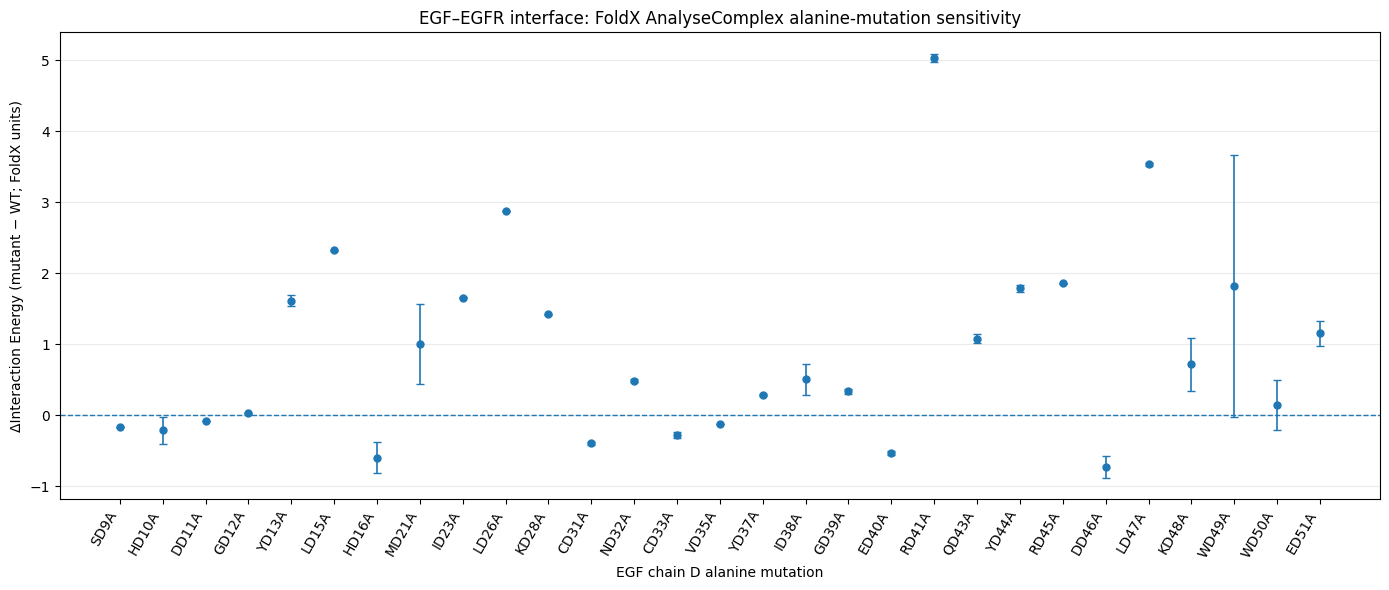

Figure saved:
/Users/robertobruzzese/Desktop/venv/foldx_02c_binding_validation/A06_A07_final_results/A06_AnalyseComplex_deltaInteraction_29_residues.png


In [26]:
# ============================================================
# A06 — Final figure:
# FoldX AnalyseComplex interaction-energy sensitivity
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Ordine per posizione nella sequenza EGF
plot_df = summary.sort_values("position").copy()

x = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(14, 6))

ax.errorbar(
    x,
    plot_df["mean_delta_interaction"],
    yerr=plot_df["sd_delta_interaction"],
    fmt="o",
    capsize=3,
    linewidth=1.2,
    markersize=5
)

# Reference line: no change relative to WT
ax.axhline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_xticks(x)
ax.set_xticklabels(
    plot_df["mutation"],
    rotation=60,
    ha="right"
)

ax.set_xlabel("EGF chain D alanine mutation")
ax.set_ylabel(
    "ΔInteraction Energy "
    "(mutant − WT; FoldX units)"
)

ax.set_title(
    "EGF–EGFR interface: FoldX AnalyseComplex "
    "alanine-mutation sensitivity"
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

FIGURE_OUT = (
    EXPORT_DIR /
    "A06_AnalyseComplex_deltaInteraction_29_residues.png"
)

fig.savefig(
    FIGURE_OUT,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:")
print(FIGURE_OUT.resolve())

## Optional comparison with 02b BuildModel results

If a CSV exported by 02b is available, set its path below. The notebook will merge it by chain-D residue position. The original `>1.5 kcal/mol` classification remains explicitly a **BuildModel mutation-energy sensitivity** criterion.

No new “binding hotspot” label is assigned unless you deliberately define and justify a separate interaction-energy criterion.

## Interpretation checklist

After execution, answer these questions before changing any downstream PEARL pipeline:

- Are the `AnalyseComplex` headers and the selected interaction-energy field unambiguous?
- Were all intended chain-D mutations generated?
- Are the replicate values reasonably consistent?
- Which residues show the largest reproducible change in B–D interaction energy?
- How much do those residues overlap with the 15 high-sensitivity residues from 02b?
- Does the peptide seed/window selected downstream depend on residues whose interpretation changes?

**Do not rerun downstream pipelines automatically.** First compare the old and new residue sets. Only dependencies affected by a materially changed selection need to be reconsidered.

### Methodological limitation

This notebook strengthens the distinction between **total mutation-energy sensitivity** and **inter-chain interaction-energy sensitivity** within FoldX. It still does not constitute experimental validation, and the FoldX interaction score should not be presented as a measured binding free energy or as proof that a designed peptide/small molecule inhibits EGFR.